In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE


___

<p style="color:red;font-size:80px"> Understand credit_record data

In [2]:
credit_record=pd.read_csv('/kaggle/input/credit-card-approval-prediction/credit_record.csv')

In [3]:
credit_record.columns

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')

In [4]:
credit_record.shape

(1048575, 3)

In [5]:
credit_record['STATUS'].unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

X = No loan / No credit yet

0 = Paid on time

1 = 1 month delay

2 = 2 months delay

3 = 3 months delay

4 = 4 months delay

5 = 5+ months delay

C = Account closed

MONTHS_BALANCE=>Number of months before the last registration date in the system

___

<p style="color:red;font-size:80px">understand application_record data

In [6]:
application_record=pd.read_csv('/kaggle/input/credit-card-approval-prediction/application_record.csv')

In [7]:
application_record.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [8]:
application_record.shape

(438557, 18)

  [1]'ID'-->primary key to connect with credit record

,[2]'CODE_GENDER'-->male or female

,[3]'FLAG_OWN_CAR' -->Indicates whether the applicant owns a car (Y = Yes, N = No)

,[4]'FLAG_OWN_REALTY'-->Indicates if the applicant owns real estate property (e.g., house or apartment)

, [5]'CNT_CHILDREN'-->Number of children the applicant is responsible for

, [6]'AMT_INCOME_TOTAL' -->Total annual income of the applicant (numeric, financial indicator)

, [7]'NAME_INCOME_TYPE' -->Type/source of income (e.g., Working, Pensioner, Student, Unemployed)

,[8]'NAME_EDUCATION_TYPE'-->Applicant’s highest completed education level.

, [9]'NAME_FAMILY_STATUS'-->Applicant’s marital/family status (e.g., Married, Single, Civil marriage).

,[10]'NAME_HOUSING_TYPE'-->Applicant’s housing type (e.g., Owned, Rented, House/apartment).

,[11]'DAYS_BIRTH'-->Age of applicant in days (negative value; convert to age by -DAYS_BIRTH/365).

, [12]'DAYS_EMPLOYED'-->Length of employment in days (negative values; large positive values often indicate unemployment or missing information)

, [13]'FLAG_MOBIL'-->Indicates if the applicant has a mobile phone (binary).

,[14]'FLAG_WORK_PHONE'-->Indicates if the applicant has a work phone number (binary).

,[15]'FLAG_PHONE'-->Indicates the presence of a personal phone number (binary).

,[16]'FLAG_EMAIL'-->Indicates if the applicant provided an email address (binary).

,[17]'OCCUPATION_TYPE'-->Applicant’s occupation category (e.g., Sales staff, Managers, Accountants).

,[18]'CNT_FAM_MEMBERS'-->Total number of family members living with the applicant.

_____

<p style="color:red;font-size:80px">preprocessing to credit_record

## [1]chk Values

In [9]:
for col in credit_record.columns:
    print(col,' --> ',credit_record[col].unique())

ID  -->  [5001711 5001712 5001713 ... 5150484 5150485 5150487]
MONTHS_BALANCE  -->  [  0  -1  -2  -3  -4  -5  -6  -7  -8  -9 -10 -11 -12 -13 -14 -15 -16 -17
 -18 -19 -20 -21 -22 -23 -24 -25 -26 -27 -28 -29 -30 -31 -32 -33 -34 -35
 -36 -37 -38 -39 -40 -41 -42 -43 -44 -45 -46 -47 -48 -49 -50 -51 -52 -53
 -54 -55 -56 -57 -58 -59 -60]
STATUS  -->  ['X' '0' 'C' '1' '2' '3' '4' '5']


___

## [2]chk data_type to cols

In [10]:
for col in credit_record.columns:
    print(col,' --> ',credit_record[col].dtype)

ID  -->  int64
MONTHS_BALANCE  -->  int64
STATUS  -->  object


## note--> in status not exist excess spaces to the right and left of the word

____

## [3]chk missing values

In [11]:
credit_record.isna().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

## no missing value in credit_record data

___

## [4]chk duplicates

In [12]:
duplicate_count = credit_record.duplicated().sum()
total_rows = len(credit_record)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

duplicate_count: 0
duplication_rate: 0.00%


## no duplicates

___

## [5]Encding to  Status

0,1,2,3,4,5  --> category with ordianl

x,c -->category wihout ordianl

In [13]:
status_map = {'X': -1, 'C': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
credit_record['STATUS_NUM'] = credit_record['STATUS'].map(status_map)

In [14]:
credit_record.head(50)

,ID,MONTHS_BALANCE,STATUS,STATUS_NUM
0,5001711,0,X,-1
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
5,5001712,-1,C,0
6,5001712,-2,C,0
7,5001712,-3,C,0
8,5001712,-4,C,0
9,5001712,-5,C,0


___

## [6]feature engineering and grouped by id

In [15]:
credit_record = credit_record.sort_values(['ID','MONTHS_BALANCE'], ascending=[True, False])

# Aggregate + trend features 
def get_trend(x):
    return x.diff().mean()  #Average change between months

agg_funcs = {
    'STATUS_NUM':['max','min','mean','last', get_trend] #It will be collected according to STATUS_NUM
}

features_credit_record = credit_record.groupby('ID').agg(agg_funcs) 
features_credit_record.columns = ['STATUS_MAX','STATUS_MIN','STATUS_MEAN','STATUS_LAST','STATUS_TREND']
features_credit_record.reset_index(inplace=True)

# NUM_LATE_MONTHS
features_credit_record['NUM_LATE_MONTHS'] = credit_record.groupby('ID')['STATUS_NUM'].apply(lambda x: (x>0).sum()).values

print(features_credit_record.head(50))

         ID  STATUS_MAX  STATUS_MIN  STATUS_MEAN  STATUS_LAST  STATUS_TREND  \
0   5001711           0          -1    -0.250000            0      0.333333   
1   5001712           0           0     0.000000            0      0.000000   
2   5001713          -1          -1    -1.000000           -1      0.000000   
3   5001714          -1          -1    -1.000000           -1      0.000000   
4   5001715          -1          -1    -1.000000           -1      0.000000   
5   5001717           0           0     0.000000            0      0.000000   
6   5001718           1          -1    -0.205128           -1     -0.026316   
7   5001719           0           0     0.000000            0      0.000000   
8   5001720           1           0     0.194444            0     -0.028571   
9   5001723           0          -1    -0.741935           -1      0.000000   
10  5001724           0          -1    -0.290323           -1     -0.033333   
11  5001725           0          -1    -0.125000    

In [16]:
features_credit_record.shape

(45985, 7)

___

## [7]chk outliers

In [17]:
for col in features_credit_record.columns:
    Q1 = features_credit_record[col].quantile(0.25)
    Q3 = features_credit_record[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = features_credit_record[(features_credit_record[col] < lower_bound) | (features_credit_record[col] > upper_bound)]
    print(f"number of outliers in {col} :  {len(outliers)}")

number of outliers in ID :  0
number of outliers in STATUS_MAX :  9886
number of outliers in STATUS_MIN :  0
number of outliers in STATUS_MEAN :  6200
number of outliers in STATUS_LAST :  1
number of outliers in STATUS_TREND :  15888
number of outliers in NUM_LATE_MONTHS :  5350


Outliers Analysis – Credit Record Features

Overview:

Outliers are values that are significantly different from the rest of the data. In credit record features, not all outliers 

are errors—some represent true extreme cases, which are important for modeling credit risk.



[Feature-wise Notes:]

-->STATUS_MAX / NUM_LATE_MONTHS:

High values indicate customers with severe delays or many late months.

These are real signals for credit risk and should be retained.



-->STATUS_MEAN / STATUS_TREND:

Some extreme values may appear due to unusual sequences or missing data (e.g., 'X' → unknown).

It is reasonable to apply clipping to reduce the effect of extreme slopes while keeping meaningful patterns.



--->STATUS_LAST / STATUS_MIN:

Usually safe; few or no problematic outliers.


___

## chk NaN

In [18]:
features_credit_record.isna().sum()

ID                   0
STATUS_MAX           0
STATUS_MIN           0
STATUS_MEAN          0
STATUS_LAST          0
STATUS_TREND       399
NUM_LATE_MONTHS      0
dtype: int64

In [19]:
features_credit_record['STATUS_TREND'] = features_credit_record['STATUS_TREND'].fillna(0)

## when exist one month only trend =0 

In [20]:
features_credit_record.isna().sum()

ID                 0
STATUS_MAX         0
STATUS_MIN         0
STATUS_MEAN        0
STATUS_LAST        0
STATUS_TREND       0
NUM_LATE_MONTHS    0
dtype: int64

____

## overview on finished data 

In [21]:
features_credit_record.head(50)

,ID,STATUS_MAX,STATUS_MIN,STATUS_MEAN,STATUS_LAST,STATUS_TREND,NUM_LATE_MONTHS
0,5001711,0,-1,-0.250000,0,0.333333,0
1,5001712,0,0,0.000000,0,0.000000,0
2,5001713,-1,-1,-1.000000,-1,0.000000,0
3,5001714,-1,-1,-1.000000,-1,0.000000,0
4,5001715,-1,-1,-1.000000,-1,0.000000,0
5,5001717,0,0,0.000000,0,0.000000,0
6,5001718,1,-1,-0.205128,-1,-0.026316,2
7,5001719,0,0,0.000000,0,0.000000,0
8,5001720,1,0,0.194444,0,-0.028571,7
9,5001723,0,-1,-0.741935,-1,0.000000,0


In [22]:
features_credit_record.shape

(45985, 7)

## in first

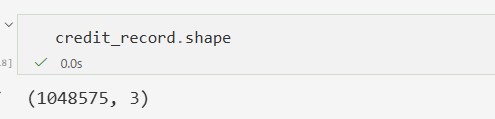

In [23]:
for col in features_credit_record.columns:
    print(col,' --> ',features_credit_record[col].dtype)

ID  -->  int64
STATUS_MAX  -->  int64
STATUS_MIN  -->  int64
STATUS_MEAN  -->  float64
STATUS_LAST  -->  int64
STATUS_TREND  -->  float64
NUM_LATE_MONTHS  -->  int64


In [24]:
for col in features_credit_record.columns:
    print(col,' --> ',features_credit_record[col].unique())

ID  -->  [5001711 5001712 5001713 ... 5150484 5150485 5150487]
STATUS_MAX  -->  [ 0 -1  1  3  2  4  5]
STATUS_MIN  -->  [-1  0  1]
STATUS_MEAN  -->  [-0.25        0.         -1.         ...  0.91666667  2.20833333
  1.60606061]
STATUS_LAST  -->  [ 0 -1  1  5]
STATUS_TREND  -->  [ 0.33333333  0.         -0.02631579 -0.02857143 -0.03333333 -0.14285714
 -0.025       0.1         0.09090909 -0.05        0.02173913 -0.05263158
  0.07142857  0.14285714  0.0625     -0.07692308 -0.03125     0.04166667
 -0.03846154 -0.09090909 -0.01754386  0.03703704 -0.05405405 -0.04761905
 -0.03703704  0.06666667 -0.02702703  0.03030303  0.03448276 -0.01851852
 -0.01960784  0.02       -0.03030303 -0.33333333 -0.02380952 -0.01818182
 -0.1        -0.5         0.03333333 -0.01785714 -0.07142857 -0.03448276
 -0.02040816 -0.04545455 -0.02941176 -0.02       -0.01886792  0.11111111
 -0.11111111  0.125       0.04545455  0.02272727 -0.02564103  0.03125
 -0.02439024 -0.02325581 -0.2        -0.05555556  0.02325581 -0.062

____

<p style="color:red;font-size:80px">preprocesssing to application_record

## [1]chk data type

In [25]:
for col in application_record.columns:
    print(col,' --> ',application_record[col].dtype)

ID  -->  int64
CODE_GENDER  -->  object
FLAG_OWN_CAR  -->  object
FLAG_OWN_REALTY  -->  object
CNT_CHILDREN  -->  int64
AMT_INCOME_TOTAL  -->  float64
NAME_INCOME_TYPE  -->  object
NAME_EDUCATION_TYPE  -->  object
NAME_FAMILY_STATUS  -->  object
NAME_HOUSING_TYPE  -->  object
DAYS_BIRTH  -->  int64
DAYS_EMPLOYED  -->  int64
FLAG_MOBIL  -->  int64
FLAG_WORK_PHONE  -->  int64
FLAG_PHONE  -->  int64
FLAG_EMAIL  -->  int64
OCCUPATION_TYPE  -->  object
CNT_FAM_MEMBERS  -->  float64


In [26]:
for col in application_record.columns:
    if(application_record[col].dtype==object):
     print(col,' --> ',application_record[col].dtype)

CODE_GENDER  -->  object
FLAG_OWN_CAR  -->  object
FLAG_OWN_REALTY  -->  object
NAME_INCOME_TYPE  -->  object
NAME_EDUCATION_TYPE  -->  object
NAME_FAMILY_STATUS  -->  object
NAME_HOUSING_TYPE  -->  object
OCCUPATION_TYPE  -->  object


____

In [27]:
application_record.shape

(438557, 18)

## [2]chk Values

In [28]:
for col in application_record.columns:
 print(col,' --> ',application_record[col].unique())

ID  -->  [5008804 5008805 5008806 ... 6841878 6842765 6842885]
CODE_GENDER  -->  ['M' 'F']
FLAG_OWN_CAR  -->  ['Y' 'N']
FLAG_OWN_REALTY  -->  ['Y' 'N']
CNT_CHILDREN  -->  [ 0  1  3  2  4  5 14 19  7  9 12  6]
AMT_INCOME_TOTAL  -->  [ 427500.    112500.    270000.    283500.    135000.    130500.
  157500.    405000.    211500.    360000.    126000.    315000.
  247500.    297000.    225000.    166500.    216000.    255150.
  148500.    202500.     94500.    450000.    180000.     90000.
  765000.    382500.    144000.    229500.    292500.     74250.
   40500.    337500.    193500.    267750.    139500.     67500.
  252000.    900000.    115290.    279000.     76500.    234000.
   81000.    108000.     99000.    198000.     45000.    238500.
  117000.    153000.   1350000.    445500.    495000.     85500.
  306000.    562500.    189000.    328500.    310500.    540000.
  171000.    675000.    121500.     72000.     65250.    184500.
  103500.    162000.    165150.     54000.    243000.

In [29]:
for col in application_record.columns:
    if(application_record[col].dtype==object):
     print(col,' --> ',application_record[col].unique())

CODE_GENDER  -->  ['M' 'F']
FLAG_OWN_CAR  -->  ['Y' 'N']
FLAG_OWN_REALTY  -->  ['Y' 'N']
NAME_INCOME_TYPE  -->  ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']
NAME_EDUCATION_TYPE  -->  ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']
NAME_FAMILY_STATUS  -->  ['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']
NAME_HOUSING_TYPE  -->  ['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']
OCCUPATION_TYPE  -->  [nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


___

## [3]Feature engineering 

In [30]:
application_record['AGE'] = (-application_record['DAYS_BIRTH'] / 365).astype(int)


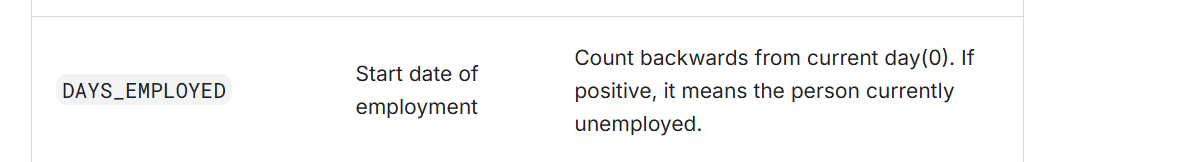

In [31]:
application_record['EMPLOYED'] = application_record['DAYS_EMPLOYED'] != 365243
application_record['YEARS_EMPLOYED'] = application_record['DAYS_EMPLOYED'].apply(lambda x: max(-x / 365, 0) if x != 365243 else 0)

remove DAYS_BIRTH ,DAYS_EMPOLYED

In [32]:
application_record.drop(['DAYS_EMPLOYED','DAYS_BIRTH'],axis=1,inplace=True)

In [33]:
application_record['INCOME_PER_PERSON'] = (
    application_record['AMT_INCOME_TOTAL'] / 
    application_record['CNT_FAM_MEMBERS']
)

In [34]:
application_record['INCOME_AGE_RATIO'] = application_record['AMT_INCOME_TOTAL'] / application_record['AGE']

In [35]:
application_record['INCOME_EMPLOY_RATIO'] = application_record.apply(
    lambda row: row['AMT_INCOME_TOTAL'] / row['YEARS_EMPLOYED'] if row['YEARS_EMPLOYED'] > 0 else row['AMT_INCOME_TOTAL'], axis=1
)


In [36]:
application_record['CHILD_RATIO'] = application_record['CNT_CHILDREN'] / application_record['CNT_FAM_MEMBERS']

____________

## [4]chk missing values

In [37]:
application_record.isna().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
AGE                         0
EMPLOYED                    0
YEARS_EMPLOYED              0
INCOME_PER_PERSON           0
INCOME_AGE_RATIO            0
INCOME_EMPLOY_RATIO         0
CHILD_RATIO                 0
dtype: int64

In [38]:
application_record.isna().mean() * 100

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
AGE                     0.000000
EMPLOYED                0.000000
YEARS_EMPLOYED          0.000000
INCOME_PER_PERSON       0.000000
INCOME_AGE_RATIO        0.000000
INCOME_EMPLOY_RATIO     0.000000
CHILD_RATIO             0.000000
dtype: float64

 Pensioners 

 Unemployed 

 Housewives / Househusbands

 Students

In [39]:
application_record['OCCUPATION_TYPE'] = application_record['OCCUPATION_TYPE'].fillna('Unknown')

In [40]:
application_record.isna().mean() * 100

ID                     0.0
CODE_GENDER            0.0
FLAG_OWN_CAR           0.0
FLAG_OWN_REALTY        0.0
CNT_CHILDREN           0.0
AMT_INCOME_TOTAL       0.0
NAME_INCOME_TYPE       0.0
NAME_EDUCATION_TYPE    0.0
NAME_FAMILY_STATUS     0.0
NAME_HOUSING_TYPE      0.0
FLAG_MOBIL             0.0
FLAG_WORK_PHONE        0.0
FLAG_PHONE             0.0
FLAG_EMAIL             0.0
OCCUPATION_TYPE        0.0
CNT_FAM_MEMBERS        0.0
AGE                    0.0
EMPLOYED               0.0
YEARS_EMPLOYED         0.0
INCOME_PER_PERSON      0.0
INCOME_AGE_RATIO       0.0
INCOME_EMPLOY_RATIO    0.0
CHILD_RATIO            0.0
dtype: float64

____

## [5]chk duplicates

In [41]:
duplicate_count = application_record.duplicated().sum()
total_rows = len(application_record)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

duplicate_count: 0
duplication_rate: 0.00%


## no dublicates

___

## [6]Encoding

[1]Binary
---------------------------------------------
FLAG_OWN_CAR  -->  ['Y' 'N']

FLAG_OWN_REALTY  -->  ['Y' 'N']




[2]category without ordinal
-------------------------------------------------
CODE_GENDER  -->  ['M' 'F']


NAME_INCOME_TYPE  -->  ['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']

NAME_FAMILY_STATUS  -->  ['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']

NAME_HOUSING_TYPE  -->  ['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']

OCCUPATION_TYPE  -->  [nan 'Security staff' 'Sales staff' 'Accountants' 'Laborers' 'Managers'
 'Drivers' 'Core staff' 'High skill tech staff' 'Cleaning staff'
 'Private service staff' 'Cooking staff' 'Low-skill Laborers'
 'Medicine staff' 'Secretaries' 'Waiters/barmen staff' 'HR staff'
 'Realty agents' 'IT staff']


[3]category with ordinal
-------------------------------------------------
NAME_EDUCATION_TYPE  -->  ['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

In [42]:
application_record.shape

(438557, 23)

In [43]:
binary_features = [
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY'
]

nominal_features = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]


ordinal_features = [
    'NAME_EDUCATION_TYPE'
]

In [44]:
le=LabelEncoder()
for col in binary_features:
    application_record[col]=le.fit_transform(application_record[col])

In [45]:
one = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
one_array = one.fit_transform(application_record[nominal_features])

one_df = pd.DataFrame(
    one_array,
    columns=one.get_feature_names_out(nominal_features),
    index=application_record.index
)

application_record = pd.concat(
    [application_record.drop(nominal_features, axis=1), one_df],
    axis=1
)


In [46]:
ord=OrdinalEncoder()
application_record['NAME_EDUCATION_TYPE']=ord.fit_transform(application_record[['NAME_EDUCATION_TYPE']])

In [47]:
application_record.shape

(438557, 55)

___

<p style="color:red;font-size:80px">Merge two DataFrame

In [48]:
application_record.columns

Index(['ID', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE',
       'EMPLOYED', 'YEARS_EMPLOYED', 'INCOME_PER_PERSON', 'INCOME_AGE_RATIO',
       'INCOME_EMPLOY_RATIO', 'CHILD_RATIO', 'CODE_GENDER_F', 'CODE_GENDER_M',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student',
       'NAME_INCOME_TYPE_Working', 'NAME_FAMILY_STATUS_Civil marriage',
       'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated',
       'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
       'NAME_HOUSING_TYPE_Co-op apartment',
       'NAME_HOUSING_TYPE_House / apartment',
       'NAME_HOUSING_TYPE_Municipal apartment',
       'NAME_HOUSING_TYPE_Office apartment',
       'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents',
       

In [49]:
features_credit_record.columns

Index(['ID', 'STATUS_MAX', 'STATUS_MIN', 'STATUS_MEAN', 'STATUS_LAST',
       'STATUS_TREND', 'NUM_LATE_MONTHS'],
      dtype='object')

In [50]:
df = application_record.merge(features_credit_record, on='ID', how='left')

In [51]:
df['HAS_CREDIT_HISTORY'] = df['STATUS_MAX'].notna().astype(int) #return T/F and convert to 0,1 --> 1 if notna , 0 if na

credit_cols = ['STATUS_MAX','STATUS_MIN','STATUS_MEAN','STATUS_LAST','STATUS_TREND','NUM_LATE_MONTHS']
df[credit_cols] = df[credit_cols].fillna(0)#instead of NAN -->0 in rows not have credit card


In [52]:
df['HAS_CREDIT_HISTORY'].unique()

array([1, 0])

In [53]:
df.shape

(438557, 62)

In [54]:
df.columns

Index(['ID', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_EDUCATION_TYPE', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE',
       'EMPLOYED', 'YEARS_EMPLOYED', 'INCOME_PER_PERSON', 'INCOME_AGE_RATIO',
       'INCOME_EMPLOY_RATIO', 'CHILD_RATIO', 'CODE_GENDER_F', 'CODE_GENDER_M',
       'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student',
       'NAME_INCOME_TYPE_Working', 'NAME_FAMILY_STATUS_Civil marriage',
       'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated',
       'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
       'NAME_HOUSING_TYPE_Co-op apartment',
       'NAME_HOUSING_TYPE_House / apartment',
       'NAME_HOUSING_TYPE_Municipal apartment',
       'NAME_HOUSING_TYPE_Office apartment',
       'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents',
       

In [55]:
df.head()

,ID,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff,STATUS_MAX,STATUS_MIN,STATUS_MEAN,STATUS_LAST,STATUS_TREND,NUM_LATE_MONTHS,HAS_CREDIT_HISTORY
0,5008804,1,1,0,427500.0,1.0,1,1,0,0,...,0.0,1.0,0.0,1.0,-1.0,0.000000,-1.0,-0.066667,1.0,1
1,5008805,1,1,0,427500.0,1.0,1,1,0,0,...,0.0,1.0,0.0,1.0,-1.0,0.000000,-1.0,-0.071429,1.0,1
2,5008806,1,1,0,112500.0,4.0,1,0,0,0,...,1.0,0.0,0.0,0.0,-1.0,-0.533333,-1.0,-0.034483,0.0,1
3,5008808,0,1,0,270000.0,4.0,1,0,1,1,...,0.0,0.0,0.0,0.0,-1.0,-0.600000,-1.0,-0.250000,0.0,1
4,5008809,0,1,0,270000.0,4.0,1,0,1,1,...,0.0,0.0,0.0,-1.0,-1.0,-1.000000,-1.0,0.000000,0.0,1


In [56]:
df.isna().sum()

ID                    0
FLAG_OWN_CAR          0
FLAG_OWN_REALTY       0
CNT_CHILDREN          0
AMT_INCOME_TOTAL      0
                     ..
STATUS_MEAN           0
STATUS_LAST           0
STATUS_TREND          0
NUM_LATE_MONTHS       0
HAS_CREDIT_HISTORY    0
Length: 62, dtype: int64

In [57]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)
duplication_rate = (duplicate_count / total_rows) * 100

print(f"duplicate_count: {duplicate_count}")
print(f"duplication_rate: {duplication_rate:.2f}%")

duplicate_count: 0
duplication_rate: 0.00%


In [58]:
for col in df.columns:
    print(col,' --> ',df[col].dtype)

ID  -->  int64
FLAG_OWN_CAR  -->  int64
FLAG_OWN_REALTY  -->  int64
CNT_CHILDREN  -->  int64
AMT_INCOME_TOTAL  -->  float64
NAME_EDUCATION_TYPE  -->  float64
FLAG_MOBIL  -->  int64
FLAG_WORK_PHONE  -->  int64
FLAG_PHONE  -->  int64
FLAG_EMAIL  -->  int64
CNT_FAM_MEMBERS  -->  float64
AGE  -->  int64
EMPLOYED  -->  bool
YEARS_EMPLOYED  -->  float64
INCOME_PER_PERSON  -->  float64
INCOME_AGE_RATIO  -->  float64
INCOME_EMPLOY_RATIO  -->  float64
CHILD_RATIO  -->  float64
CODE_GENDER_F  -->  float64
CODE_GENDER_M  -->  float64
NAME_INCOME_TYPE_Commercial associate  -->  float64
NAME_INCOME_TYPE_Pensioner  -->  float64
NAME_INCOME_TYPE_State servant  -->  float64
NAME_INCOME_TYPE_Student  -->  float64
NAME_INCOME_TYPE_Working  -->  float64
NAME_FAMILY_STATUS_Civil marriage  -->  float64
NAME_FAMILY_STATUS_Married  -->  float64
NAME_FAMILY_STATUS_Separated  -->  float64
NAME_FAMILY_STATUS_Single / not married  -->  float64
NAME_FAMILY_STATUS_Widow  -->  float64
NAME_HOUSING_TYPE_Co-op apartm

<p style="color:red;font-size:80px">Create target

In [59]:
def make_target(row):
    if row['STATUS_LAST'] > 0 or row['STATUS_MAX'] > 0:
        return 0  # good client
    else:
        return 1  # bad client

df['TARGET'] = df.apply(make_target, axis=1)

print(df['TARGET'].value_counts())


TARGET
1    434266
0      4291
Name: count, dtype: int64


In [60]:
df.head()

,ID,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_EDUCATION_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,...,OCCUPATION_TYPE_Unknown,OCCUPATION_TYPE_Waiters/barmen staff,STATUS_MAX,STATUS_MIN,STATUS_MEAN,STATUS_LAST,STATUS_TREND,NUM_LATE_MONTHS,HAS_CREDIT_HISTORY,TARGET
0,5008804,1,1,0,427500.0,1.0,1,1,0,0,...,1.0,0.0,1.0,-1.0,0.000000,-1.0,-0.066667,1.0,1,0
1,5008805,1,1,0,427500.0,1.0,1,1,0,0,...,1.0,0.0,1.0,-1.0,0.000000,-1.0,-0.071429,1.0,1,0
2,5008806,1,1,0,112500.0,4.0,1,0,0,0,...,0.0,0.0,0.0,-1.0,-0.533333,-1.0,-0.034483,0.0,1,1
3,5008808,0,1,0,270000.0,4.0,1,0,1,1,...,0.0,0.0,0.0,-1.0,-0.600000,-1.0,-0.250000,0.0,1,1
4,5008809,0,1,0,270000.0,4.0,1,0,1,1,...,0.0,0.0,-1.0,-1.0,-1.000000,-1.0,0.000000,0.0,1,1


<p style="color:red;font-size:80px"> Visualization[Exploratory Data Analysis EDA]

<p style="color:green;font-size:80px">STATUS_MAX and STATUS_MIN cols

Text(0, 0.5, 'Frequency')

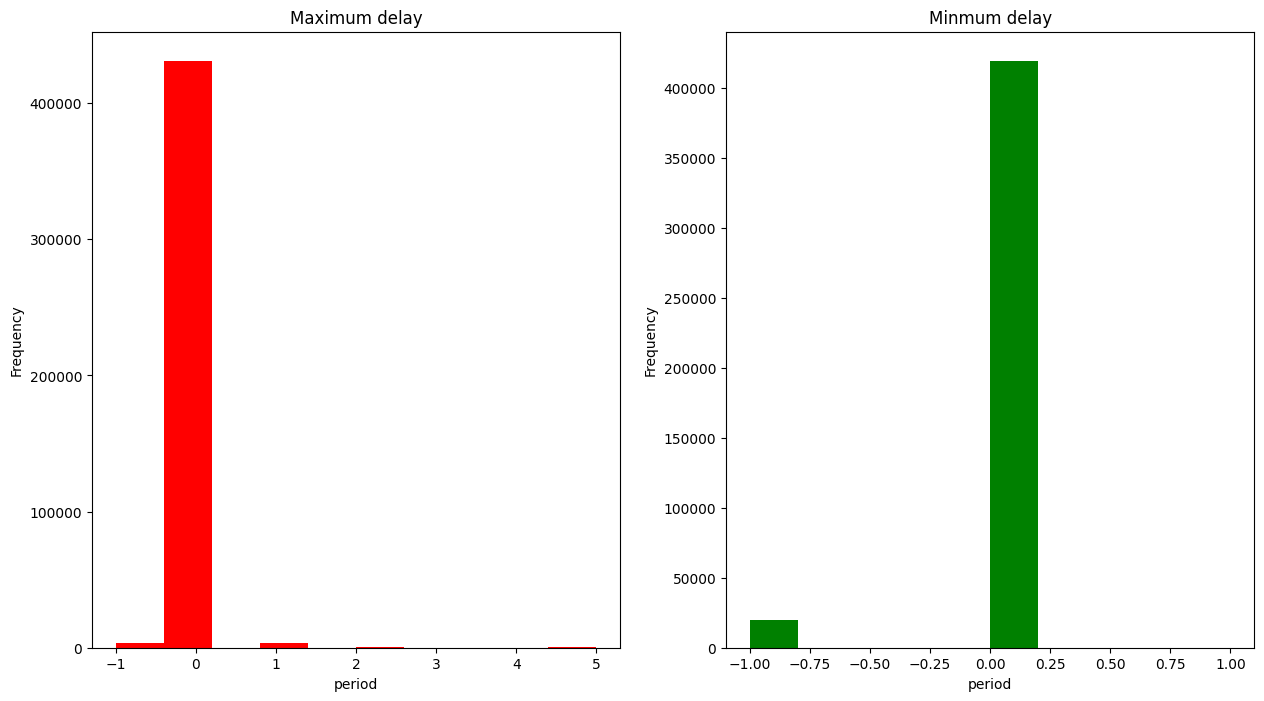

In [61]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(15, 8), sharex=False)

ax1.hist(df['STATUS_MAX'],color='r')
ax1.set_title('Maximum delay')
ax1.set_xlabel('period')
ax1.set_ylabel('Frequency')

ax2.hist(df['STATUS_MIN'],color='g')
ax2.set_title('Minmum delay')
ax2.set_xlabel('period')
ax2.set_ylabel('Frequency')

X = No loan / No credit yet

C = Account closed

0 = Paid on time

1 = 1 month delay

2 = 2 months delay

3 = 3 months delay

4 = 4 months delay

5 = 5+ months delay

'X': -1, 

'C': 0, 

'0': 0, 

'1': 1, 

'2': 2, 

'3': 3, 

'4': 4, 

'5': 5

For each id it's maximum status [at most] 0 --> account closed or paid on time and [at least] 1 --> one month delay and -1 --> no credit card and in a [very small] percentage 2,5

for each id it's mininmum status [at most] 0 --> account closed or paid on time But here it tends towards one more and [at least] -1 --> no credit card

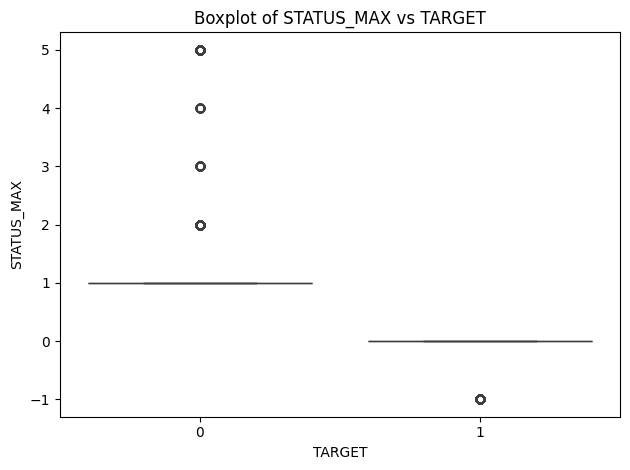

In [62]:
sns.boxplot(x='TARGET', y='STATUS_MAX', data=df)
plt.title(f'Boxplot of STATUS_MAX vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MAX')
plt.tight_layout()
plt.show()

target is 1  approval if status max it's mean 0  --> closed , paid on tome

target is 0 not approval if status max it's mean 1 -->one month delayed and 2,3,4,5 monthts delayed

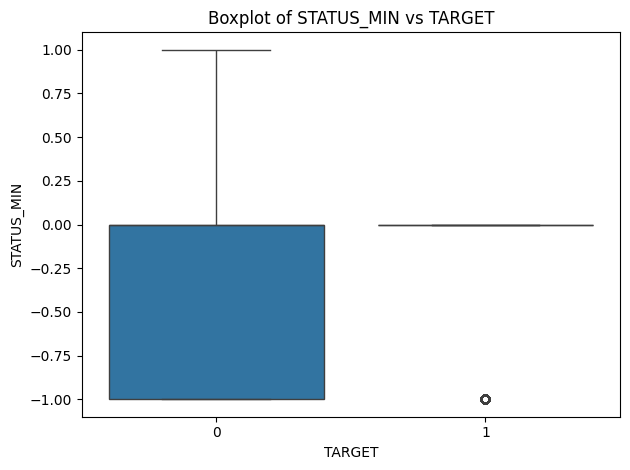

In [63]:
sns.boxplot(x='TARGET', y='STATUS_MIN', data=df)
plt.title(f'Boxplot of STATUS_MIN vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MIN')
plt.tight_layout()
plt.show()

target is 1  approval if status min it's mean 0  --> closed , paid on tome

target is 0 not approval if status min [at most] 0 --> closed , paid on tome and -1  no credt card , [at least] 1 -->one month delayed

___

<p style="color:green;font-size:80px">STATUS_MEAN col

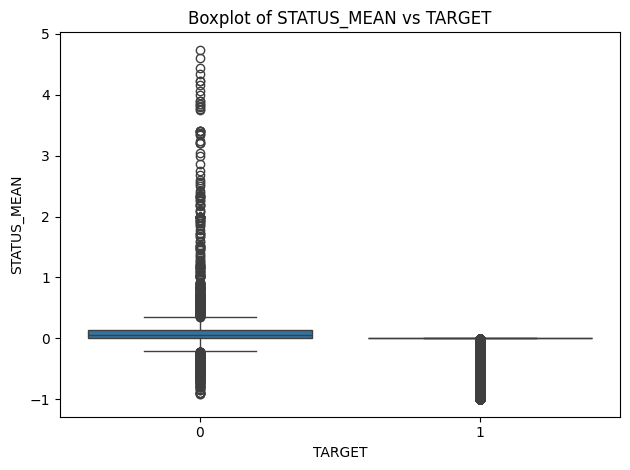

In [64]:
sns.boxplot(x='TARGET', y='STATUS_MEAN', data=df)
plt.title(f'Boxplot of STATUS_MEAN vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_MEAN')
plt.tight_layout()
plt.show()

in 1 target not exist delayed (1,2,3,4,5) such as 0 target

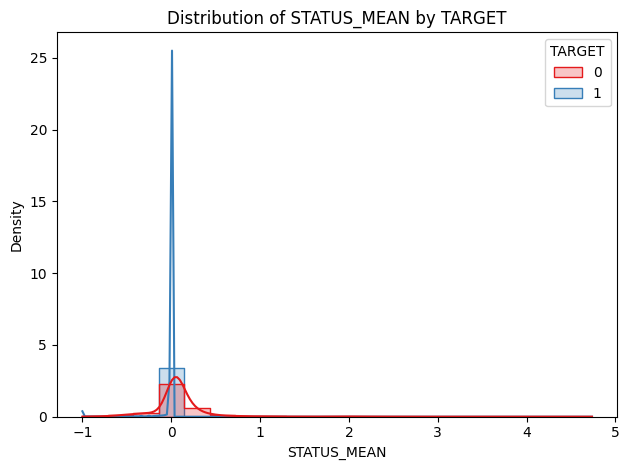

In [65]:
sns.histplot(data=df, x='STATUS_MEAN', hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
plt.title(f'Distribution of {'STATUS_MEAN'} by TARGET')
plt.xlabel('STATUS_MEAN')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

Target 1 is greater in the area around 1, and Target 0 is also in this area but less than 1. Target 0 is also in the area beyond 0 in the direction of 1.

___

<p style="color:green;font-size:80px">STATUS_TREND col

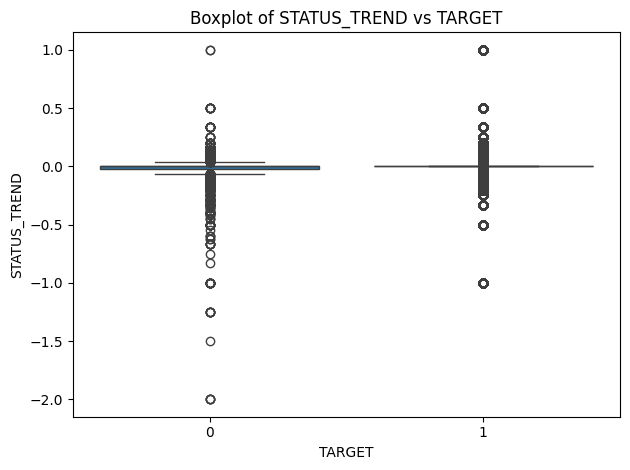

In [66]:
sns.boxplot(x='TARGET', y='STATUS_TREND', data=df)
plt.title(f'Boxplot of STATUS_TREND vs TARGET')
plt.xlabel('TARGET')
plt.ylabel('STATUS_TREND')
plt.tight_layout()
plt.show()

In the case of a target of zero, the situation tends to be negative, meaning that most of them do not have a credit card.

___

<p style="color:green;font-size:80px">NUM_LATE_MONTHS COL

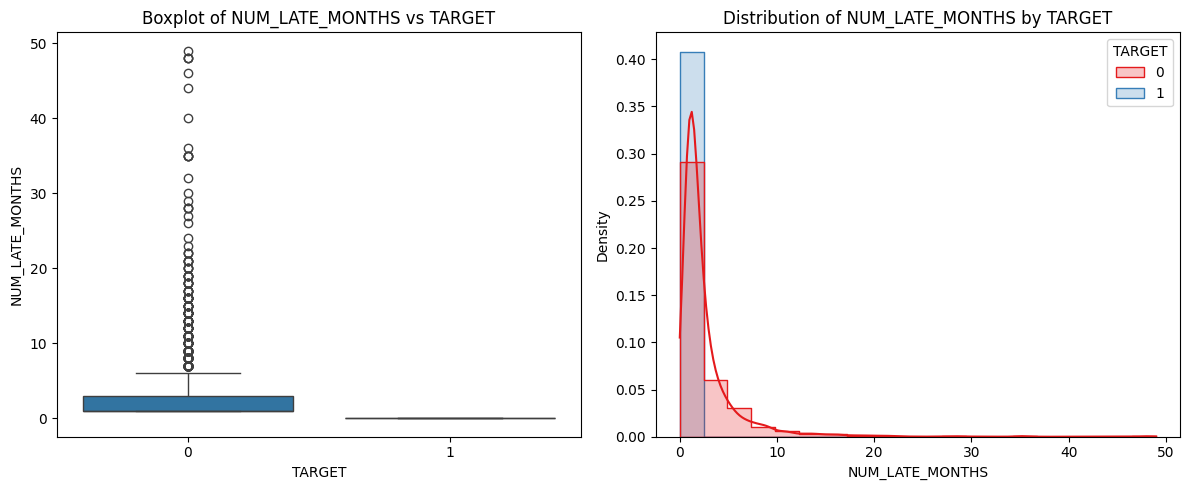

In [67]:
credit_features = ['NUM_LATE_MONTHS']

for feature in credit_features:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.boxplot(x='TARGET', y=feature, data=df)
    plt.title(f'Boxplot of {feature} vs TARGET')
    plt.xlabel('TARGET')
    plt.ylabel(feature)
   
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=feature, hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by TARGET')
    plt.xlabel(feature)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()

Target 1 means they pay on time or their account is closed, but target 0 means they are many months late in payment

___

<p style="color:green;font-size:80px">STATUS_LAST COL

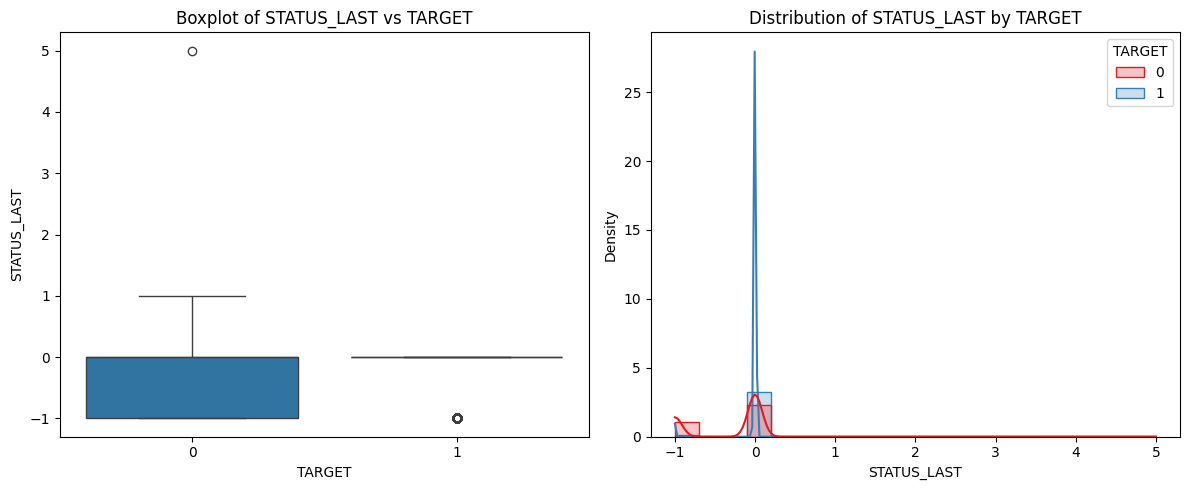

In [68]:
credit_features = ['STATUS_LAST']

for feature in credit_features:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.boxplot(x='TARGET', y=feature, data=df)
    plt.title(f'Boxplot of {feature} vs TARGET')
    plt.xlabel('TARGET')
    plt.ylabel(feature)
   
    plt.subplot(1,2,2)
    sns.histplot(data=df, x=feature, hue='TARGET', kde=True, palette='Set1', element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {feature} by TARGET')
    plt.xlabel(feature)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.show()

We have noticed many times, and here too, that in the area around 0 the target is 1, and in the area trending towards negative the target is 0.

____

<p style="color:green;font-size:80px">HAS_CREDIT_HISTORY COL

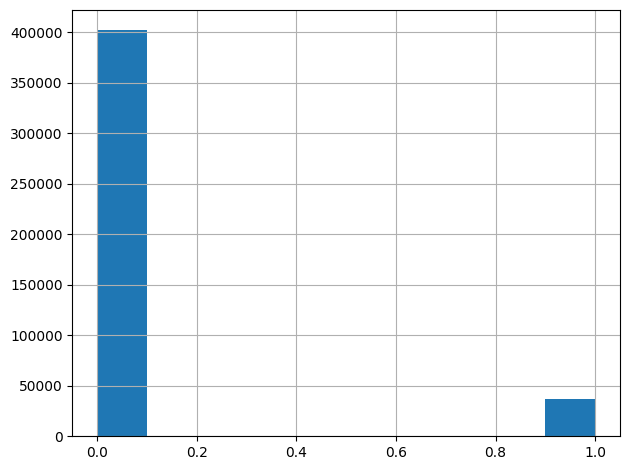

In [69]:
df['HAS_CREDIT_HISTORY'].hist()
plt.tight_layout()
plt.show()

Most people don't have a credit card.

___

<p style="color:green;font-size:80px">occupation_cols

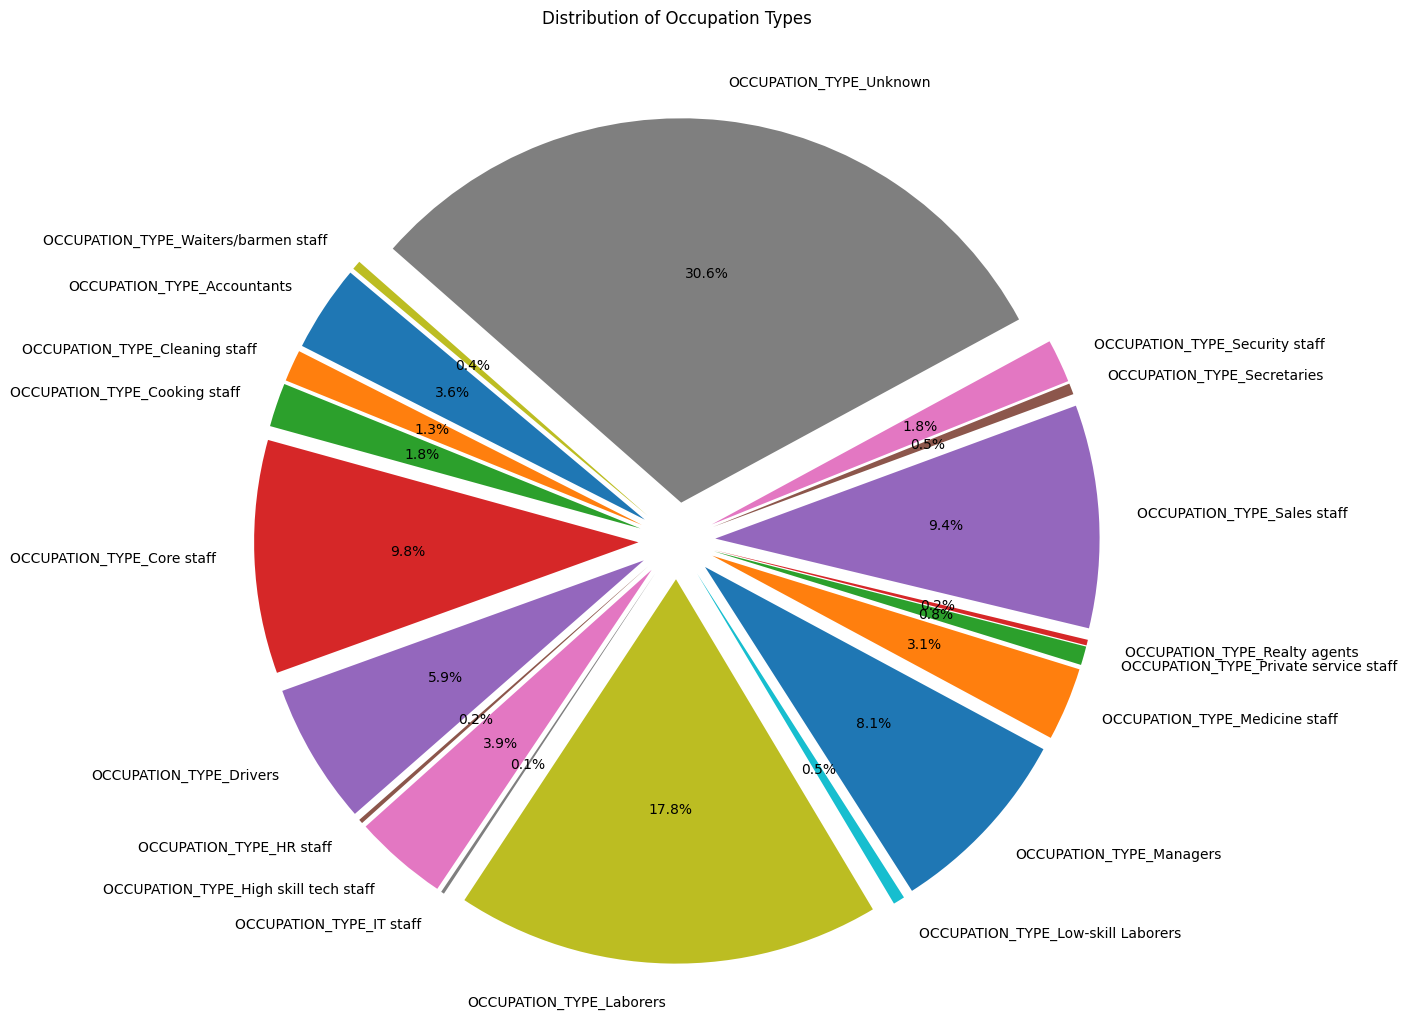

In [70]:
occupation_cols = [
    'OCCUPATION_TYPE_Accountants',
    'OCCUPATION_TYPE_Cleaning staff',
    'OCCUPATION_TYPE_Cooking staff',
    'OCCUPATION_TYPE_Core staff',
    'OCCUPATION_TYPE_Drivers',
    'OCCUPATION_TYPE_HR staff',
    'OCCUPATION_TYPE_High skill tech staff',
    'OCCUPATION_TYPE_IT staff',
    'OCCUPATION_TYPE_Laborers',
    'OCCUPATION_TYPE_Low-skill Laborers',
    'OCCUPATION_TYPE_Managers',
    'OCCUPATION_TYPE_Medicine staff',
    'OCCUPATION_TYPE_Private service staff',
    'OCCUPATION_TYPE_Realty agents',
    'OCCUPATION_TYPE_Sales staff',
    'OCCUPATION_TYPE_Secretaries',
    'OCCUPATION_TYPE_Security staff',
    'OCCUPATION_TYPE_Unknown',
    'OCCUPATION_TYPE_Waiters/barmen staff'
]

counts = df[occupation_cols].sum()

# Distances between sectors
explode = np.ones(len(counts)) * 0.1  

plt.figure(figsize=(12,12))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    explode=explode,         
    startangle=140
)
plt.title("Distribution of Occupation Types", pad=40)
plt.axis('equal')
plt.show()


In [71]:
result = {}# tuple{'OCCUPATION_TYPE':{'Target_0':count, 'Target_1':count}}
for col in occupation_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    result[col] = {'0': zeros, '1': ones}

#print(result)

result_df = pd.DataFrame(result).T
result_df.columns = ['Target_0', 'Target_1']
result_df

,Target_0,Target_1
OCCUPATION_TYPE_Accountants,147,15838
OCCUPATION_TYPE_Cleaning staff,63,5782
OCCUPATION_TYPE_Cooking staff,86,7990
OCCUPATION_TYPE_Core staff,463,42544
OCCUPATION_TYPE_Drivers,264,25826
OCCUPATION_TYPE_HR staff,14,760
OCCUPATION_TYPE_High skill tech staff,181,17108
OCCUPATION_TYPE_IT staff,11,593
OCCUPATION_TYPE_Laborers,730,77510
OCCUPATION_TYPE_Low-skill Laborers,33,2107


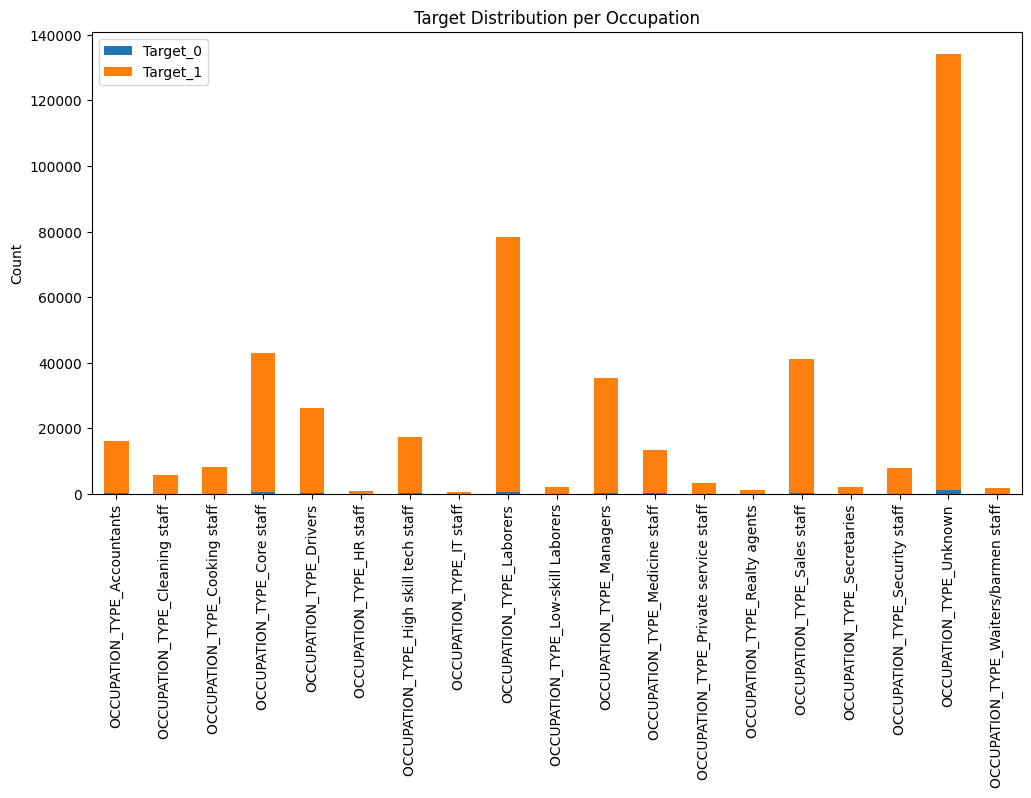

In [72]:
result_df.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Target Distribution per Occupation")
plt.ylabel("Count")
plt.show()

This expresses the general idea of ​​which job is acceptable and which is rejected.

In [73]:
status_cols = ['STATUS_MAX', 'STATUS_MIN']

status_summary = {}

for occ in occupation_cols:
    #rows have occupation = 1 bescause it encoded
    df_occ = df[df[occ] == 1]
    
    #print(df_occ) # all df when  occupation = 1

    max_val = df_occ['STATUS_MAX'].max() #for each occupation
    min_val = df_occ['STATUS_MIN'].min()
    
    status_summary[occ] = {'STATUS_MAX': max_val, 'STATUS_MIN': min_val} #for each occupation

#convert to DataFrame
status_df = pd.DataFrame(status_summary).T # T instead on occuption is col make ir rows
status_df

,STATUS_MAX,STATUS_MIN
OCCUPATION_TYPE_Accountants,5.0,-1.0
OCCUPATION_TYPE_Cleaning staff,5.0,-1.0
OCCUPATION_TYPE_Cooking staff,5.0,-1.0
OCCUPATION_TYPE_Core staff,5.0,-1.0
OCCUPATION_TYPE_Drivers,5.0,-1.0
OCCUPATION_TYPE_HR staff,2.0,-1.0
OCCUPATION_TYPE_High skill tech staff,5.0,-1.0
OCCUPATION_TYPE_IT staff,5.0,-1.0
OCCUPATION_TYPE_Laborers,5.0,-1.0
OCCUPATION_TYPE_Low-skill Laborers,5.0,-1.0


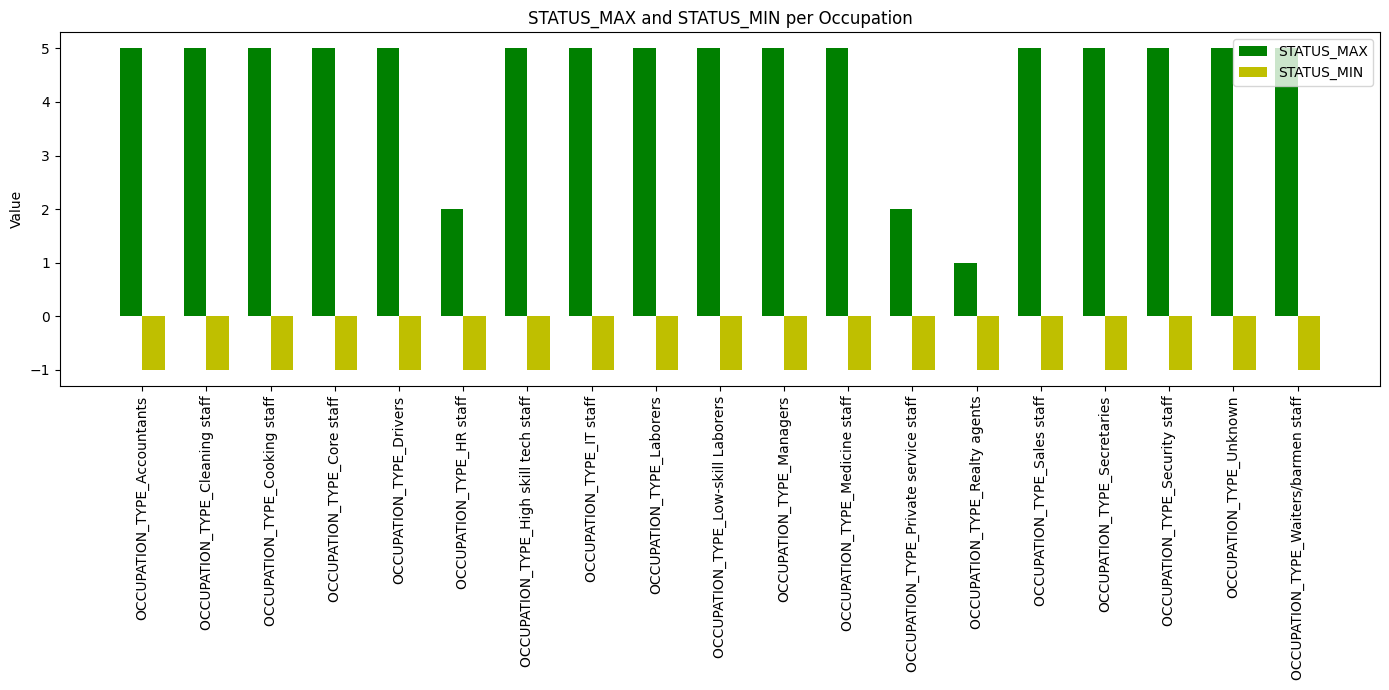

In [74]:
x = np.arange(len(status_df))
width = 0.35

#print(x)

plt.figure(figsize=(14,7))
plt.bar(x - width/2, status_df['STATUS_MAX'], width, label='STATUS_MAX', color='g')
plt.bar(x + width/2, status_df['STATUS_MIN'], width, label='STATUS_MIN', color='y')

plt.xticks(x, status_df.index, rotation=90)
plt.ylabel("Value")
plt.title("STATUS_MAX and STATUS_MIN per Occupation")
plt.legend()
plt.tight_layout()
plt.show()


## Occupation type: Real estate agents are the least likely to experience delays.

## To see, on average, how long each job might take to pay.

___

<p style="color:green;font-size:80px">housing_cols

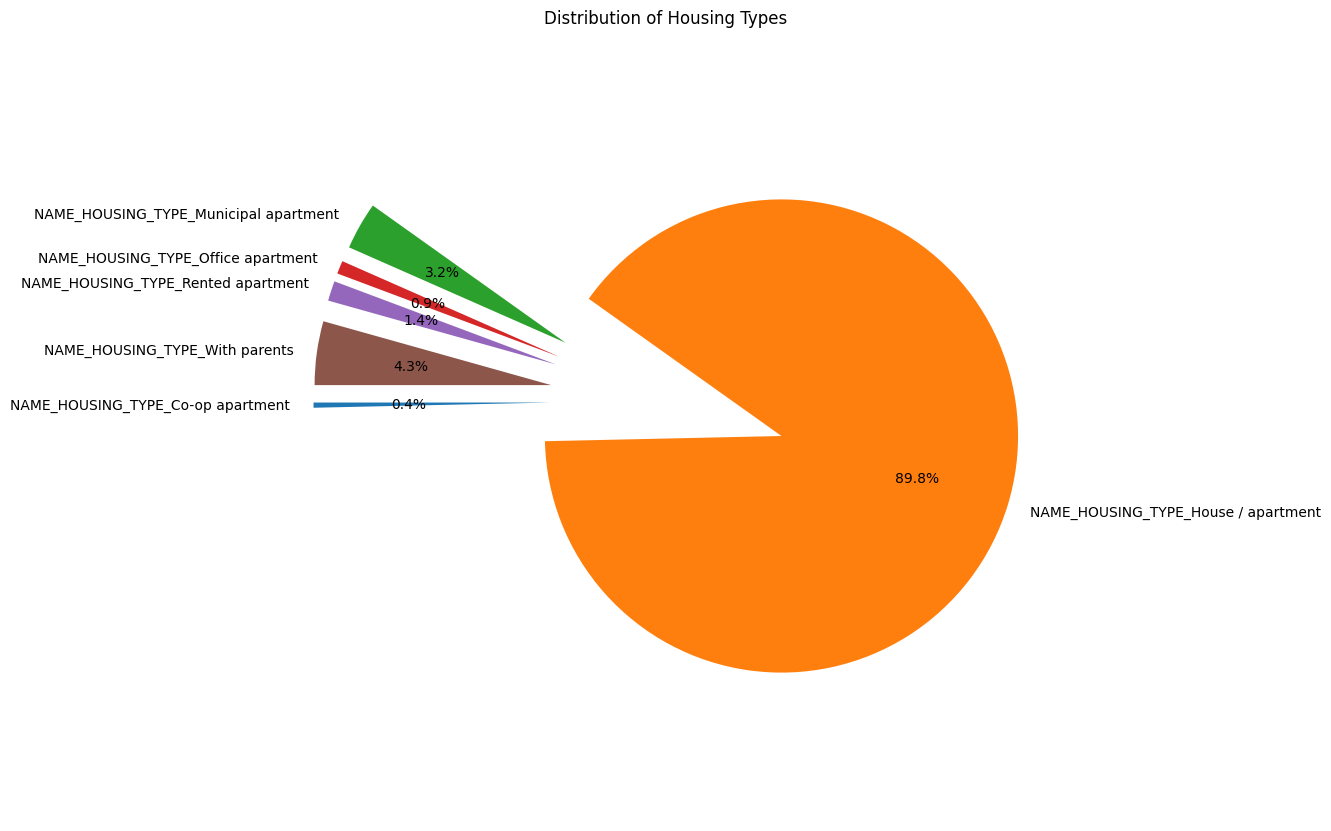

In [75]:
housing_cols = [
    'NAME_HOUSING_TYPE_Co-op apartment',
    'NAME_HOUSING_TYPE_House / apartment',
    'NAME_HOUSING_TYPE_Municipal apartment',
    'NAME_HOUSING_TYPE_Office apartment',
    'NAME_HOUSING_TYPE_Rented apartment',
    'NAME_HOUSING_TYPE_With parents'
]

# count each type
housing_counts = df[housing_cols].sum()

explode = [0.5]*len(housing_counts)  # distance between sectors
plt.figure(figsize=(10,10))
plt.pie(
    housing_counts,
    labels=housing_counts.index,
    autopct='%1.1f%%', # to Percentages
    explode=explode,
    startangle=180
)
plt.title("Distribution of Housing Types", pad=20)
plt.axis('equal')
plt.show()


## The most common type of housing is house/apartment.

In [76]:
housing_target = {}

for col in housing_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0] # encoded
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    housing_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones} # for each type 

housing_target_df = pd.DataFrame(housing_target).T
housing_target_df

,TARGET_0,TARGET_1
NAME_HOUSING_TYPE_Co-op apartment,14,1525
NAME_HOUSING_TYPE_House / apartment,3782,390049
NAME_HOUSING_TYPE_Municipal apartment,150,14064
NAME_HOUSING_TYPE_Office apartment,38,3884
NAME_HOUSING_TYPE_Rented apartment,80,5894
NAME_HOUSING_TYPE_With parents,227,18850


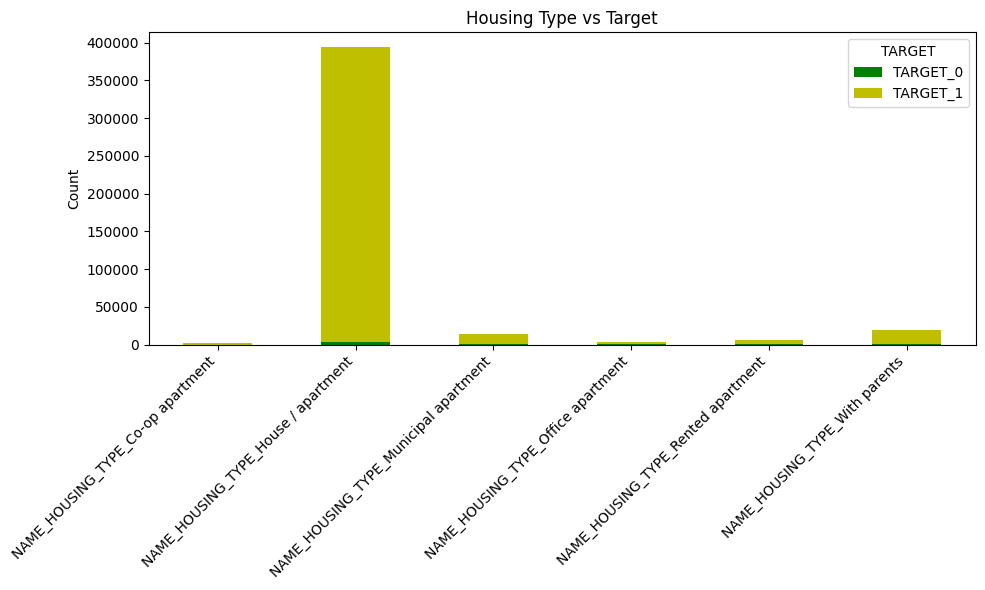

In [77]:
import matplotlib.pyplot as plt

housing_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['g','y']
)
plt.title("Housing Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()


## The name of the type of house/apartment, is more acceptable.

## The name of the type of  Co-op apartment, is less acceptable.

____

<p style="color:GREEN;font-size:80px">family_cols

In [78]:
family_cols = [
    'NAME_FAMILY_STATUS_Civil marriage',
    'NAME_FAMILY_STATUS_Married',
    'NAME_FAMILY_STATUS_Separated',
    'NAME_FAMILY_STATUS_Single / not married',
    'NAME_FAMILY_STATUS_Widow'
]

# counts for each FAMILY_STATUS
family_counts = df[family_cols].sum()

family_counts

NAME_FAMILY_STATUS_Civil marriage           36532.0
NAME_FAMILY_STATUS_Married                 299828.0
NAME_FAMILY_STATUS_Separated                27251.0
NAME_FAMILY_STATUS_Single / not married     55271.0
NAME_FAMILY_STATUS_Widow                    19675.0
dtype: float64

In [79]:
family_target = {}

for col in family_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    family_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}

family_target_df = pd.DataFrame(family_target).T
family_target_df


,TARGET_0,TARGET_1
NAME_FAMILY_STATUS_Civil marriage,367,36165
NAME_FAMILY_STATUS_Married,2914,296914
NAME_FAMILY_STATUS_Separated,225,27026
NAME_FAMILY_STATUS_Single / not married,623,54648
NAME_FAMILY_STATUS_Widow,162,19513


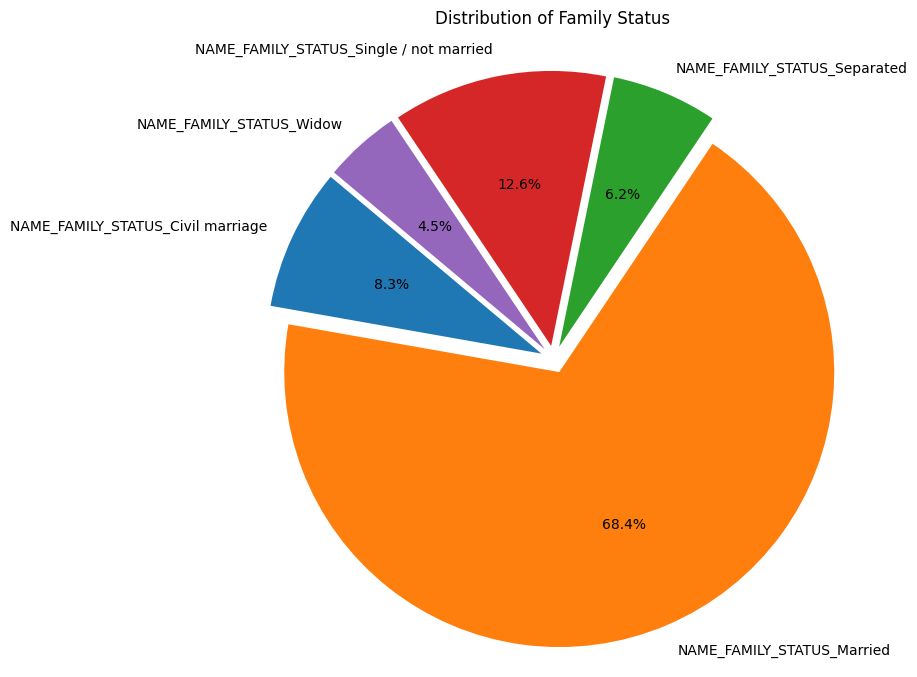

In [80]:
explode = [0.05]*len(family_counts)

plt.figure(figsize=(8,8))
plt.pie(
    family_counts, # table fro each type and it's count
    labels=family_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Family Status", pad=20)
plt.axis('equal')
plt.show()


## the most married

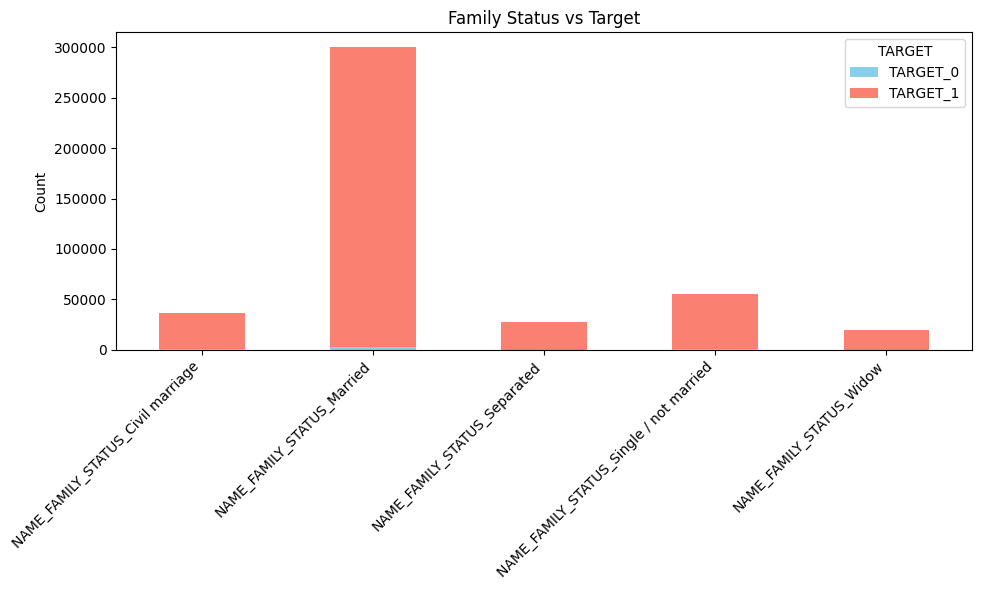

In [81]:
family_target_df.plot( # table from each type how many 0 and how many 1
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['skyblue','salmon']
)
plt.title("Family Status vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()


## Married women are the most accepted, followed by single women.

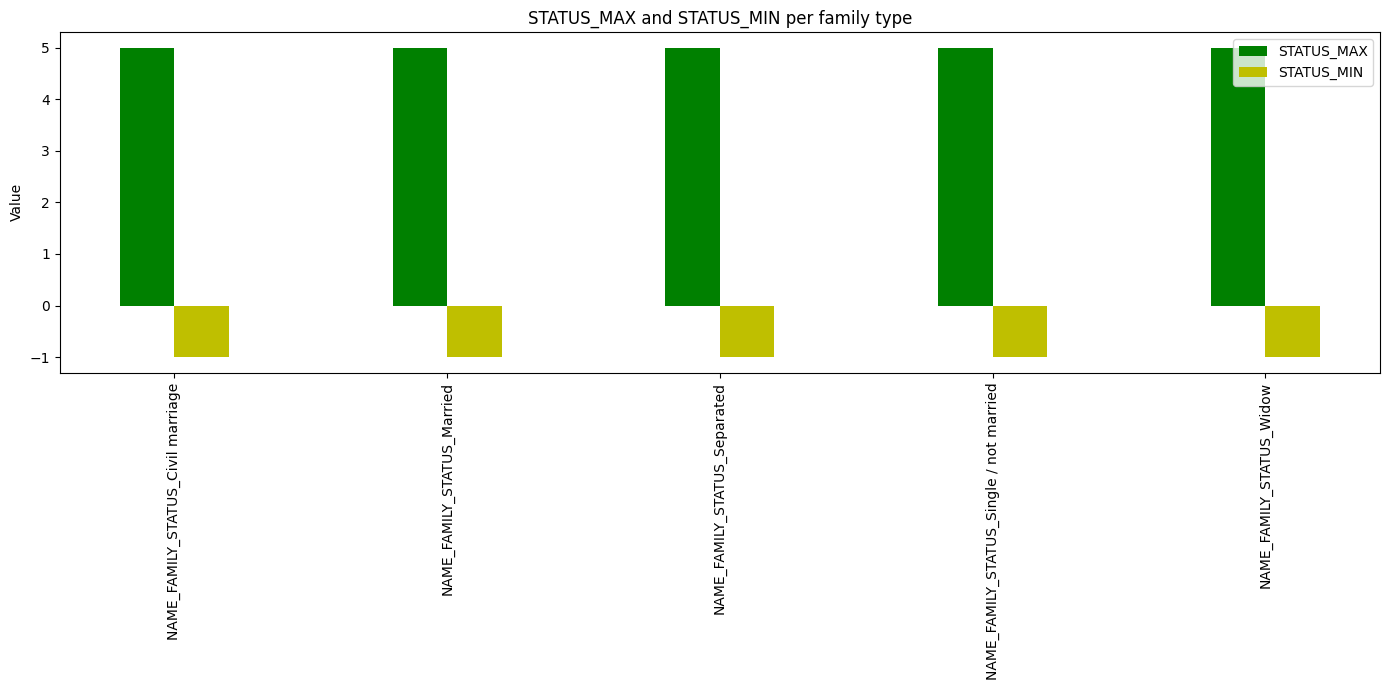

In [82]:
status_cols = ['STATUS_MAX', 'STATUS_MIN']

status_summary = {}

for fam in family_cols:
    #rows have family_cols= 1 bescause it encoded
    df_fam = df[df[fam] == 1]
    
    max_val = df_fam['STATUS_MAX'].max() #for each fam
    min_val = df_fam['STATUS_MIN'].min()
    
    status_summary[fam] = {'STATUS_MAX': max_val, 'STATUS_MIN': min_val} #for each fam

#convert to DataFrame
status_df = pd.DataFrame(status_summary).T # T instead of fam is col make ir rows
status_df


x = np.arange(len(status_df))
width = 0.2

#print(x)

plt.figure(figsize=(14,7))
plt.bar(x - width/2, status_df['STATUS_MAX'], width, label='STATUS_MAX', color='g')
plt.bar(x + width/2, status_df['STATUS_MIN'], width, label='STATUS_MIN', color='y')

plt.xticks(x, status_df.index, rotation=90)
plt.ylabel("Value")
plt.title("STATUS_MAX and STATUS_MIN per family type")
plt.legend()
plt.tight_layout()
plt.show()

_______

<p style="color:GREEN;font-size:80px">income_cols

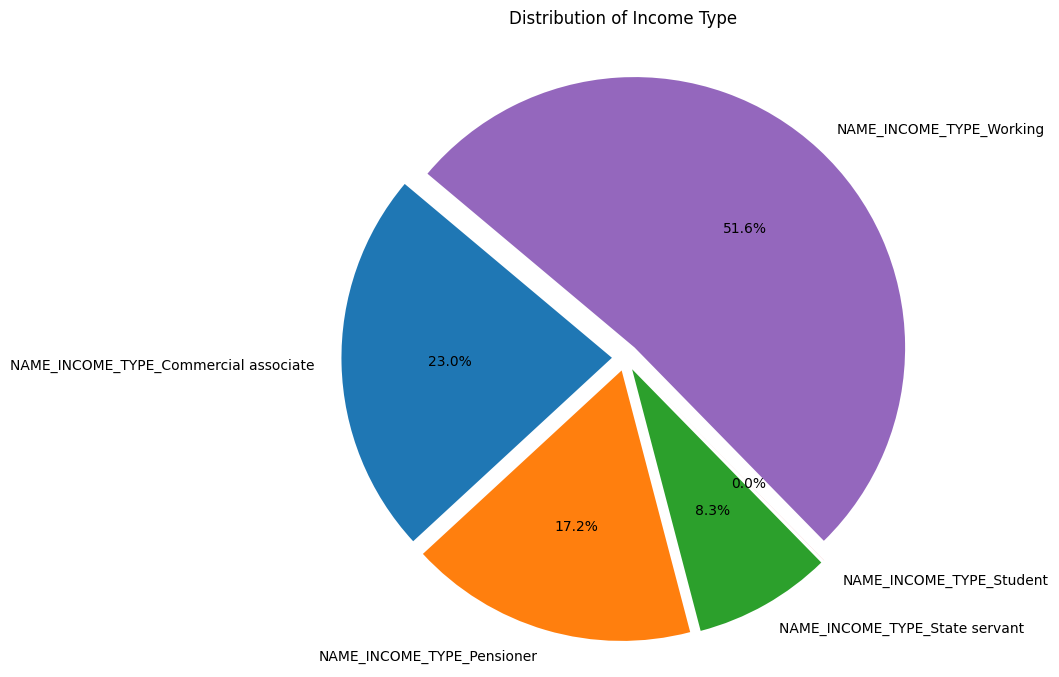

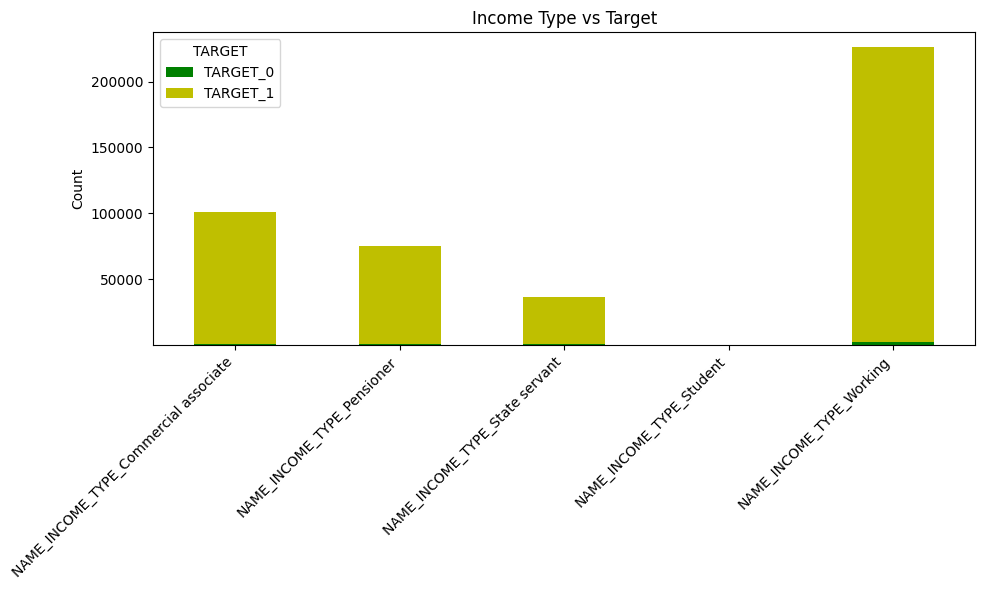

In [83]:
income_cols = [
    'NAME_INCOME_TYPE_Commercial associate',
    'NAME_INCOME_TYPE_Pensioner',
    'NAME_INCOME_TYPE_State servant',
    'NAME_INCOME_TYPE_Student',
    'NAME_INCOME_TYPE_Working'
]

# How many of each type do I have
income_counts = df[income_cols].sum()
explode = [0.05]*len(income_counts)
plt.figure(figsize=(8,8))
plt.pie(
    income_counts,
    labels=income_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Income Type", pad=20)
plt.axis('equal')
plt.show()

#--------------------------------------------------------------------------
#Each type has a zero and a one
income_target = {}
for col in income_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    income_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}
income_target_df = pd.DataFrame(income_target).T


income_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['g','y']
)
plt.title("Income Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

___

<p style="color:GREEN;font-size:80px">gender_cols

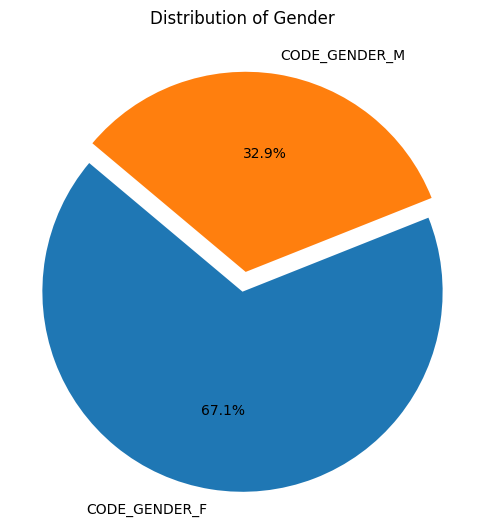

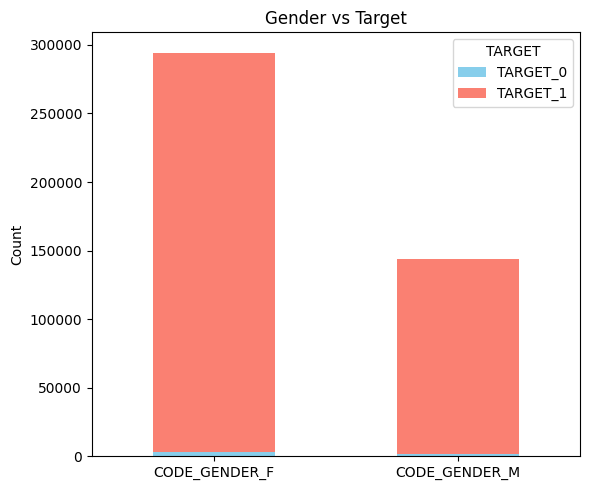

In [84]:
gender_cols = ['CODE_GENDER_F', 'CODE_GENDER_M']
gender_counts = df[gender_cols].sum()
explode = [0.05]*len(gender_counts)
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140
)
plt.title("Distribution of Gender", pad=20)
plt.axis('equal')
plt.show()



gender_target = {}
for col in gender_cols:
    zeros = df[(df[col] == 1) & (df['TARGET'] == 0)].shape[0]
    ones  = df[(df[col] == 1) & (df['TARGET'] == 1)].shape[0]
    gender_target[col] = {'TARGET_0': zeros, 'TARGET_1': ones}
gender_target_df = pd.DataFrame(gender_target).T
gender_target_df.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5),
    color=['skyblue','salmon']
)
plt.title("Gender vs Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

___

<p style="color:GREEN;font-size:80px">EDUCATION_col

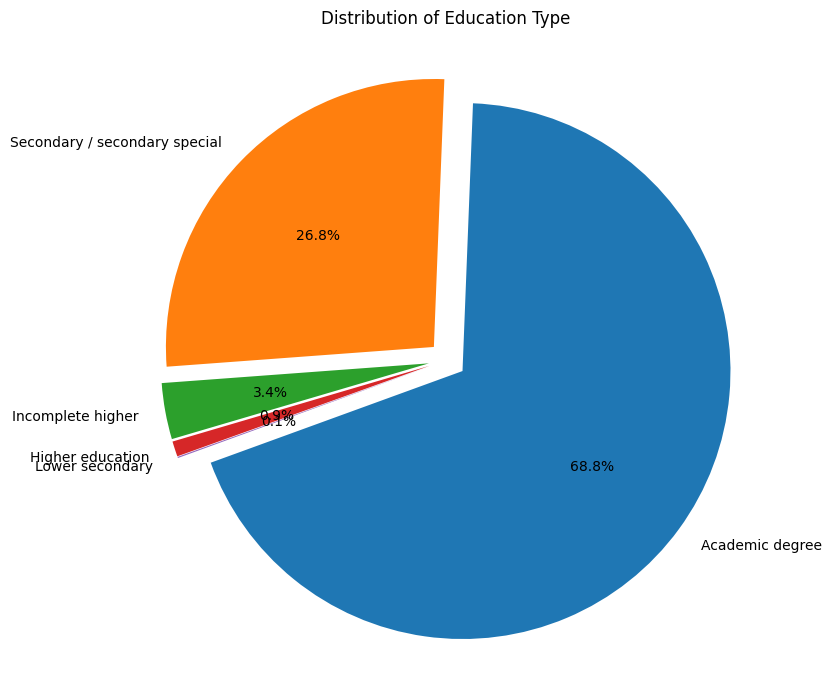

TARGET                            0       1
EDUCATION_NAME                             
Academic degree                2890  298931
Higher education                 39    4012
Incomplete higher               207   14644
Lower secondary                   7     305
Secondary / secondary special  1148  116374


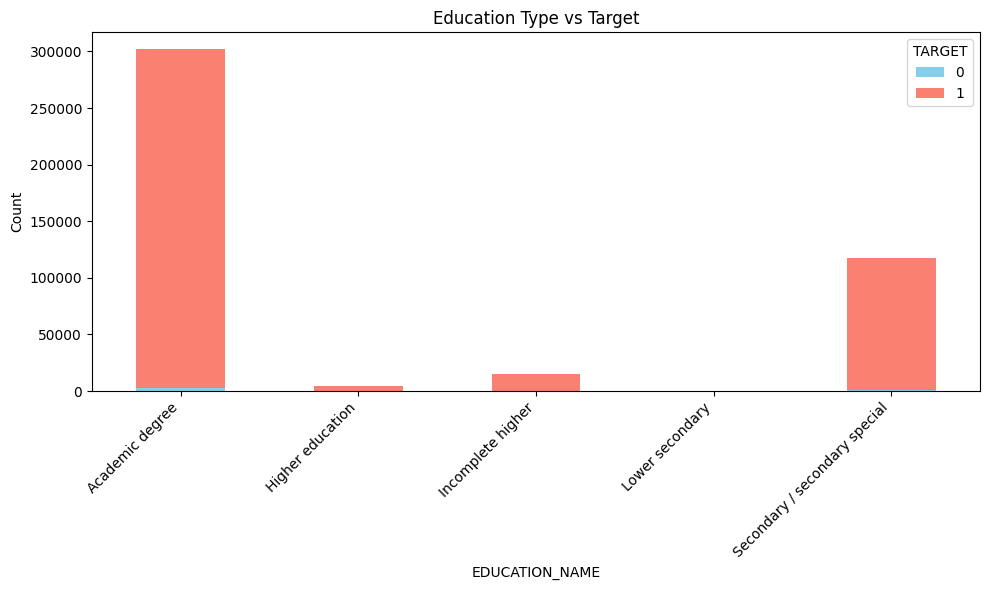

In [85]:
edu_mapping = {
    0: 'Lower secondary',
    1: 'Secondary / secondary special',
    2: 'Incomplete higher',
    3: 'Higher education',
    4: 'Academic degree'
}
# To restore the original names from encoding
df['EDUCATION_NAME'] = df['NAME_EDUCATION_TYPE'].map(edu_mapping)

education_counts = df['EDUCATION_NAME'].value_counts()#Each type has a count
plt.figure(figsize=(8,8))
plt.pie(
    education_counts,
    labels=education_counts.index,
    autopct='%1.1f%%',
    startangle=200,
    explode=[0.07]*len(education_counts)
)
plt.title("Distribution of Education Type", pad=20)
plt.axis('equal')
plt.show()


education_target = df.groupby(['EDUCATION_NAME', 'TARGET']).size().unstack(fill_value=0)# each type has how many 0 and how many 1
print(education_target)
education_target.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['skyblue','salmon']
)
plt.title("Education Type vs Target")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

In [86]:
df.drop(['EDUCATION_NAME'],axis=1,inplace=True)

____

<p style="color:GREEN;font-size:80px">Flags col

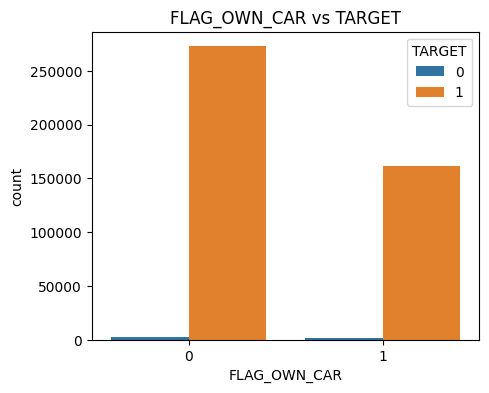

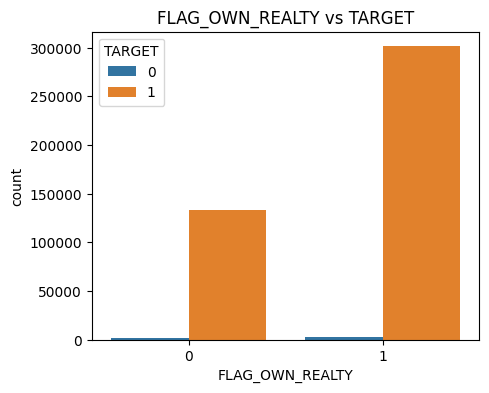

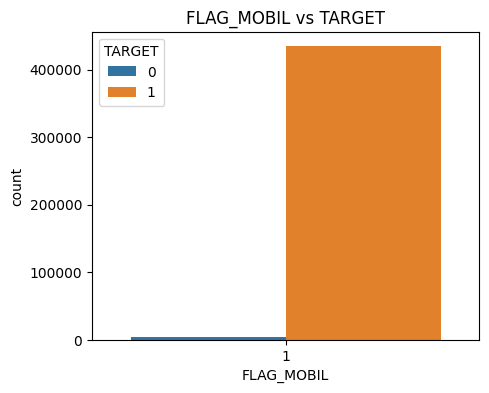

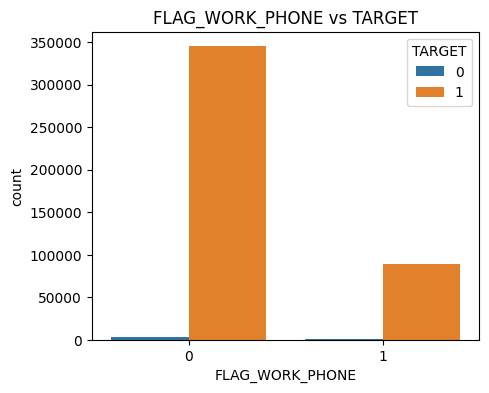

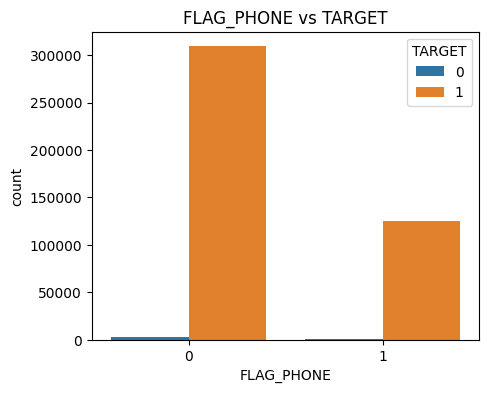

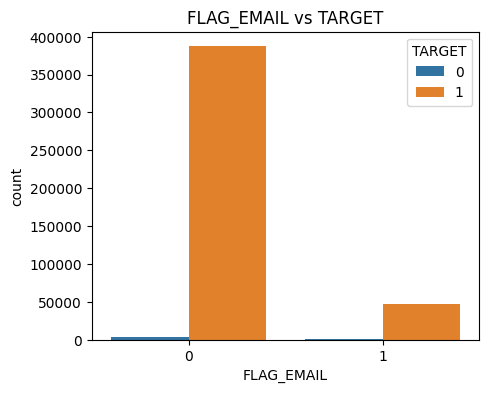

In [87]:
bool_cols = ['FLAG_OWN_CAR','FLAG_OWN_REALTY','FLAG_MOBIL','FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL']

for col in bool_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col, hue='TARGET')
    plt.title(f"{col} vs TARGET")
    plt.show()


___

<p style="color:GREEN;font-size:40px">CNT_CHILDREN , AMT_INCOME_TOTAL , CNT_FAM_MEMBERS cols

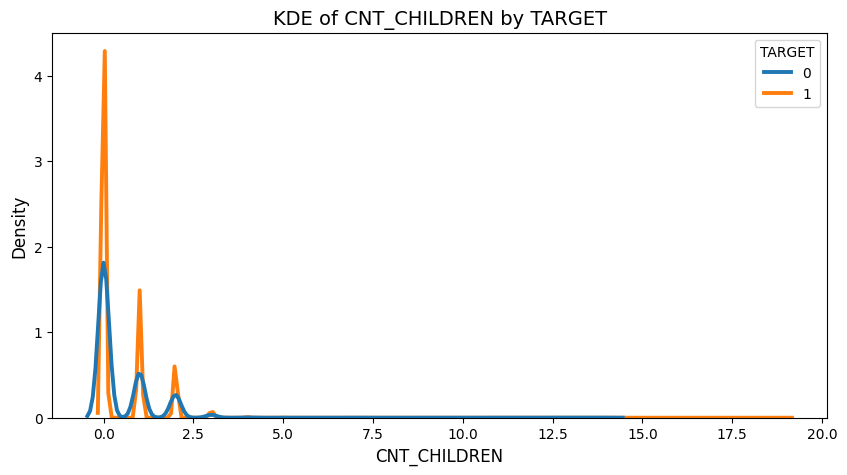

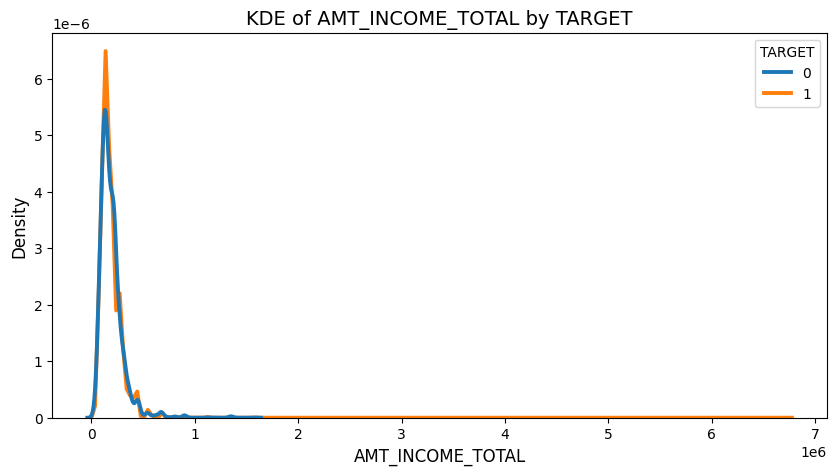

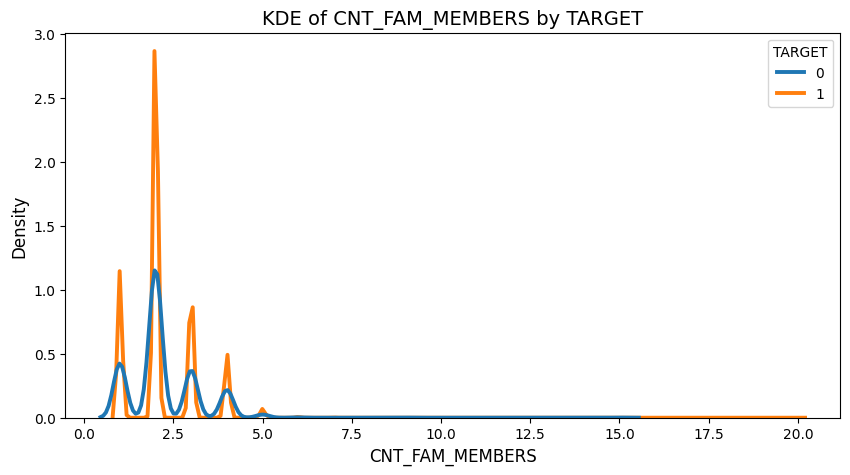

In [88]:
num_cols = ['CNT_CHILDREN','AMT_INCOME_TOTAL','CNT_FAM_MEMBERS']
for col in num_cols:
     plt.figure(figsize=(10,5)) 
     sns.kdeplot(
        data=df, 
        x=col, 
        hue='TARGET', 
        common_norm=False,
        linewidth=2.8
    )
     plt.title(f"KDE of {col} by TARGET", fontsize=14)
     plt.xlabel(col, fontsize=12)
     plt.ylabel("Density", fontsize=12)
     plt.show()

___

<p style="color:GREEN;font-size:80px">EXtracted_cols in Feature engineering

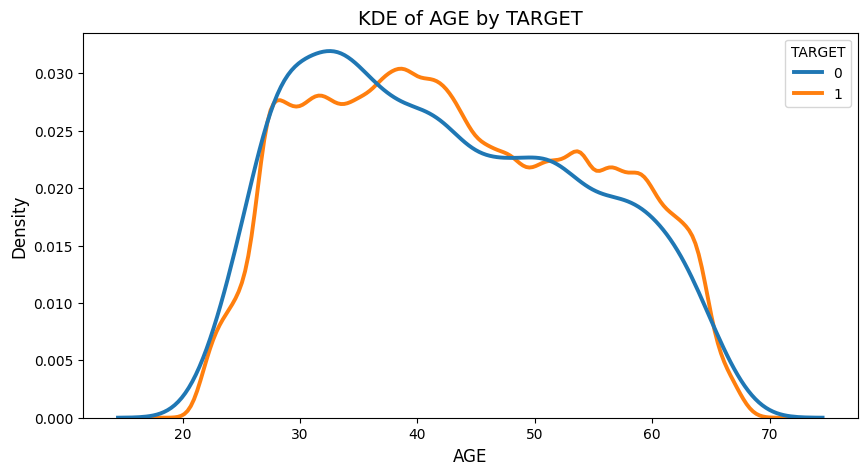

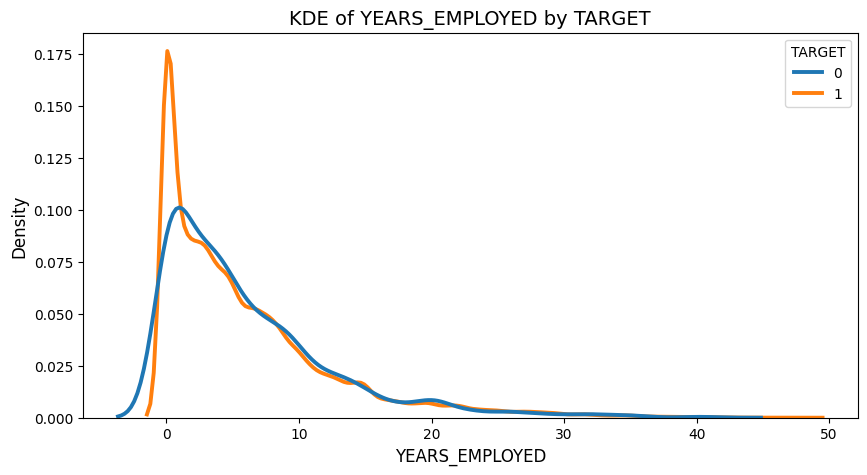

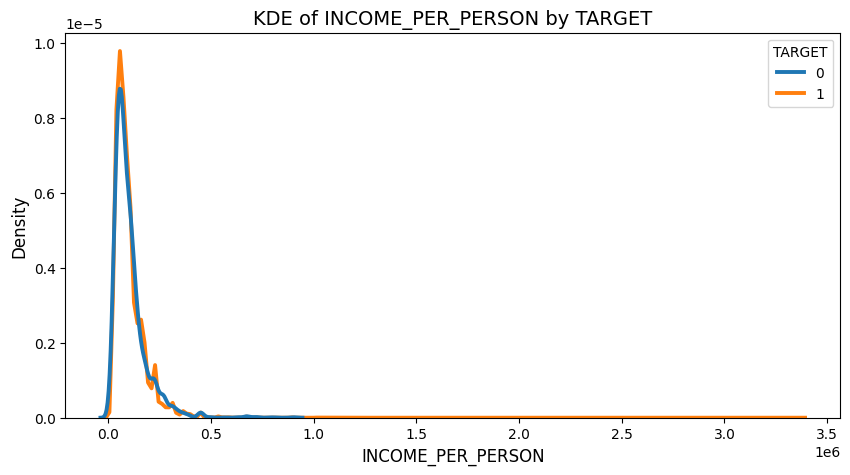

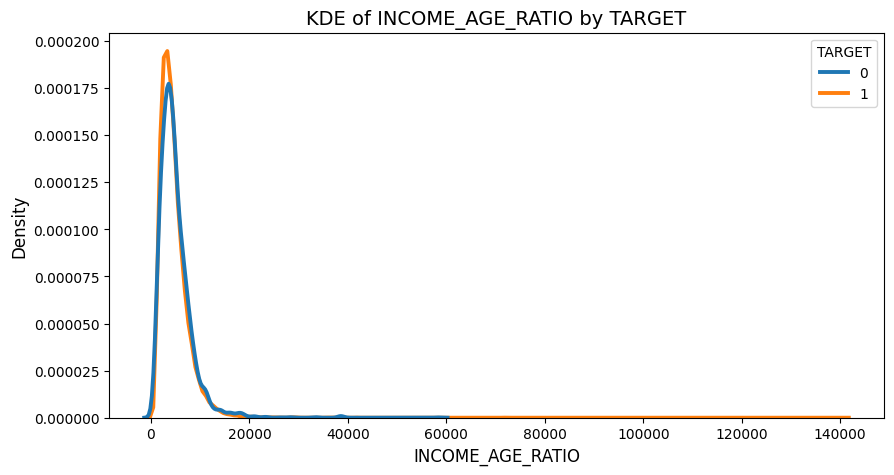

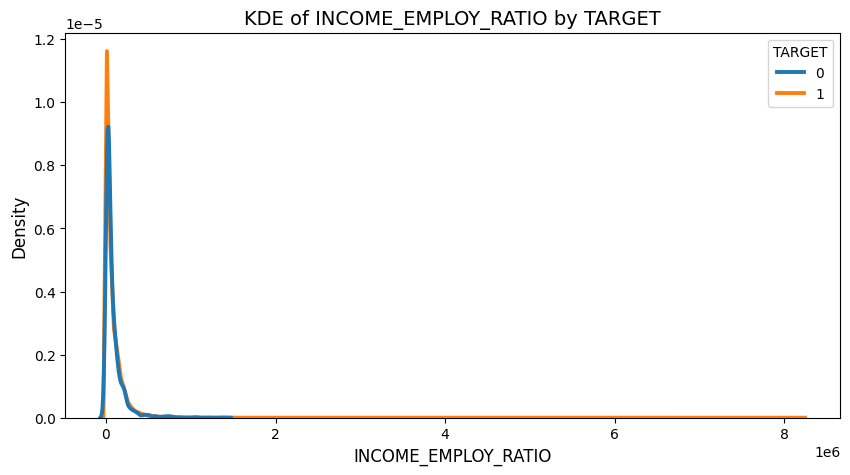

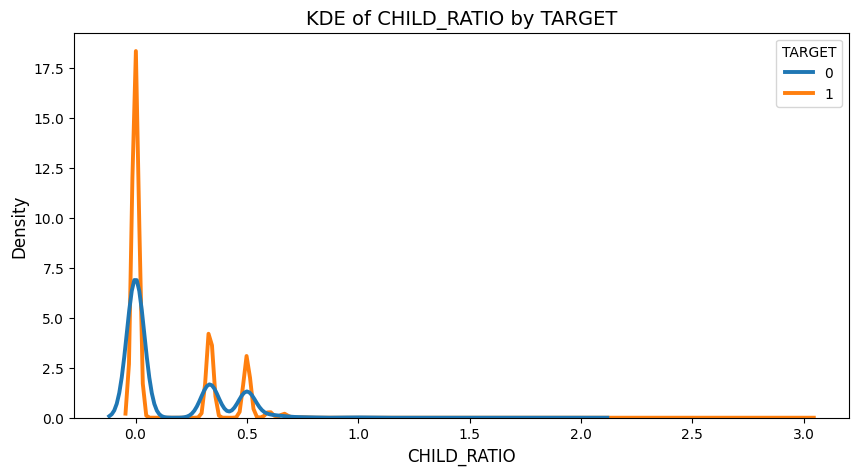

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

Extracted_features = [
    'AGE',
    'YEARS_EMPLOYED',
    'INCOME_PER_PERSON',
    'INCOME_AGE_RATIO',
    'INCOME_EMPLOY_RATIO',
    'CHILD_RATIO'
]

for col in Extracted_features:
    plt.figure(figsize=(10,5)) 
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='TARGET', 
        common_norm=False,
        linewidth=2.8
    )
    plt.title(f"KDE of {col} by TARGET", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.show()

<Axes: xlabel='EMPLOYED'>

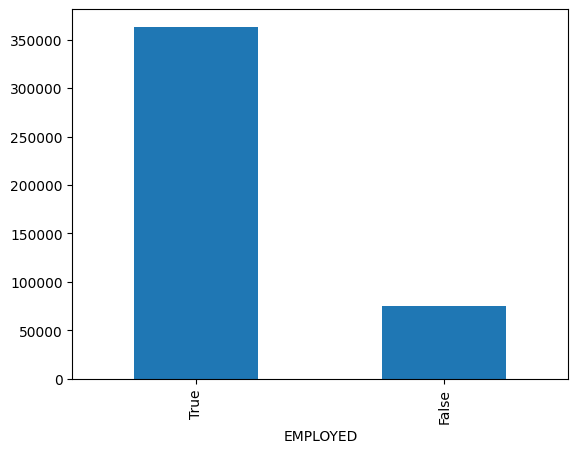

In [90]:
df['EMPLOYED'].value_counts().plot(kind='bar')

___

<p style="color:red;font-size:80px">Training

In [91]:
X = df.drop(['ID','TARGET'], axis=1)
y = df['TARGET']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [92]:
print("before SMOTE:")
print(pd.Series(y_train).value_counts())

before SMOTE:
TARGET
1    347412
0      3433
Name: count, dtype: int64


In [93]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [94]:
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

After SMOTE:
TARGET
1    347412
0    347412
Name: count, dtype: int64


In [95]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_res, y_train_res)

y_pred_log = log_model.predict_proba(X_test)[:,1]
y_pred_log_label = (y_pred_log > 0.5).astype(int)

print("Logistic Regression Metrics:")
print("AUC:", roc_auc_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log_label))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_label))

Logistic Regression Metrics:
AUC: 1.0
F1-score: 1.0
Confusion Matrix:
 [[  858     0]
 [    0 86854]]
